1. Counts the number of years between each recession
2. Counts how long each recession lasts

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def get_recession_data() -> pd.DataFrame:
    df_recession = pd.read_csv("data/USREC.csv")
    df_recession = df_recession.rename(columns={"USREC": "recession", "DATE": "date"})
    df_recession["date"] = pd.to_datetime(df_recession["date"])
    df_recession = df_recession.set_index("date")
    return df_recession

In [3]:
def average_num_months_between_recessions(start_year: int = None) -> None:
    count = 0
    months_between_rec = []
    df = get_recession_data()
    df = df[df["recession"] == 0]

    if start_year:
        df = df[df.index >= pd.Timestamp(year=start_year, month=1, day=1)]

    for i in range(len(df) - 1):
        next_month = df.index[i] + pd.DateOffset(months=1)

        if df.index[i + 1] == next_month:
            count += 1
        else:
            months_between_rec.append(count)
            count = 0

    avg = np.average(months_between_rec)

    # average time between recessions. aka peaceful time, economic prosperity
    print(
        f"average number of months between recessions since {df.index[0].year}: {round(avg)}"
    )
    print(
        f"average number of years between recessions since {df.index[0].year}: {round(avg / 12, 1)}"
    )


# average_num_months_between_recessions()
average_num_months_between_recessions(start_year=1950)

average number of months between recessions since 1950: 65
average number of years between recessions since 1950: 5.5


In [4]:
rec_df = get_recession_data()

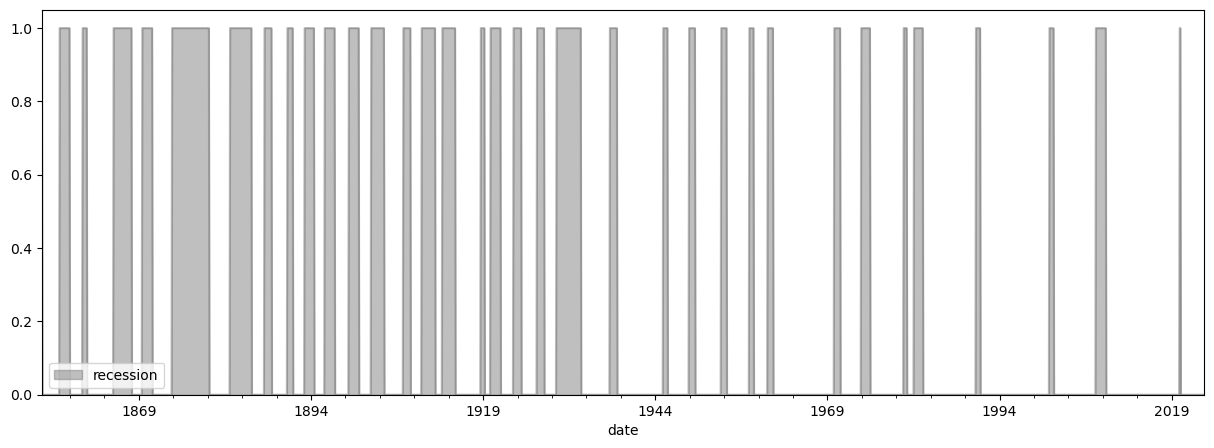

In [5]:
fig, ax = plt.subplots(figsize=(15, 5))
rec_df.plot.area(ax=ax, alpha=0.5, color="gray")
plt.show()

In [6]:
# def average_num_recession_months(start_year: int = None) -> None:
#     recession_list = []
#     df = get_recession_data()
#     count = 0
#     df = df[df["recession"] == 1]

#     if start_year:
#         df = df[df.index >= pd.Timestamp(year=start_year, month=1, day=1)]

#     for i in range(len(df) - 1):
#         next_month = df.index[i] + pd.DateOffset(months=1)

#         if df.index[i + 1] == next_month:
#             count += 1
#         else:
#             recession_list.append(count)
#             count = 0

#     avg = np.average(recession_list)

#     # average time between recessions. aka peaceful time, economic prosperity
#     print(
#         f"average number of months for recessions since {df.index[0].year}: {round(avg)}"
#     )

# average_num_recession_months()
# average_num_recession_months(start_year=1950)

In [7]:
# Number of recessions from 1945 onwards
start_year = 1945

rec_df = rec_df[rec_df.index >= pd.Timestamp(year=start_year, month=1, day=1)]

count_recession = rec_df.diff().eq(1).sum().iloc[0]
print(f"Number of recessions since {start_year}: {count_recession}")

# Number of recession months
recession_months = rec_df.eq(1).sum()

# average length of a recession
avg_rec_len = (recession_months / count_recession).iloc[0]
print(f"Average recession length since {start_year}: {round(avg_rec_len)} months")

Number of recessions since 1945: 13
Average recession length since 1945: 10 months


In [8]:
"""TODO: plot the probability of each recession alongside of the actual recessions"""

# df_recession.plot.area(ax=ax, alpha=0.5, color="gray")


from fredapi import Fred

fred = Fred(api_key="612c90fb30af12767bbcaf9513bac5ed")
recession_prob = fred.get_series("RECPROUSM156N", observation_start="1990-01-01")
recession_prob = recession_prob.dropna()
recession_prob.tail()

2023-09-01    0.06
2023-10-01    0.44
2023-11-01    0.04
2023-12-01    0.08
2024-01-01    0.26
dtype: float64

#### You may download calculated [recession probabilities](https://www.newyorkfed.org/research/capital_markets/ycfaq#/) in excel format from the Federal Reserve Bank of New York 

In [9]:
treasury_spread_recession_prob = pd.read_excel(
    "path/to/file",
    usecols=["Rec_prob", "Date"],
)
treasury_spread_recession_prob = treasury_spread_recession_prob.set_index("Date")
treasury_spread_recession_prob.tail().dropna()

FileNotFoundError: [Errno 2] No such file or directory: 'path/to/file'